Bài 1: Thống kê mô tả & đặc trưng

In [1]:

import seaborn as sns
import pandas as pd

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Dữ liệu có 150 dòng và 5 cột
Các cột của dữ liệu có các kiểu dữ liệu tương ứng như sau:
sepal_length : float64

sepal_width : float64

petal_length : float64

petal_width : float64

species : object

Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [2]:
columns = ["name_column", "mean", "median", "mode", "var", "std", "min", "max", "Q1", "Q3", "IQR"]
table = pd.DataFrame(columns=columns, index=range(4))
list_name_column = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, name in enumerate(list_name_column):
  table.iloc[i] = [name, df[name].mean(), df[name].median(), df[name].mode()[0], df[name].var(), df[name].std(), df[name].min(), df[name].max(), df[name].quantile(0.25), df[name].quantile(0.75), df[name].quantile(0.75)-df[name].quantile(0.25)]
table

,name_column,mean,median,mode,var,std,min,max,Q1,Q3,IQR
0,sepal_length,5.843333,5.8,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
1,sepal_width,3.057333,3.0,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
2,petal_length,3.758,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
3,petal_width,1.199333,1.3,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [3]:

species = set(df['species'])
print(species)
name_cot = ["name_species", "mean_sepal_length", "std_sepal_length", "mean_sepal_width", "std_sepal_width", "mean_petal_length", "std_petal_length", "mean_petal_width", "std_petal_width"]
table2 = pd.DataFrame(columns=name_cot, index=range(len(species)))
# for i, name in enumerate(species):
#     # Lọc ra một bảng phụ (subset) chỉ chứa dữ liệu của loài hiện tại (ví dụ: chỉ chứa 'versicolor')
#     subset = df[df['species'] == name]

#     # Tính mean và std trên bảng phụ này
#     table2.iloc[i] = [
#         name,
#         subset['sepal_length'].mean(), subset['sepal_length'].std(),
#         subset['sepal_width'].mean(), subset['sepal_width'].std(),
#         subset['petal_length'].mean(), subset['petal_length'].std(),
#         subset['petal_width'].mean(), subset['petal_width'].std()
#     ]
table2 = df.groupby('species').agg(['mean', 'std']).round(2)
table2


{'versicolor', 'virginica', 'setosa'}


sepal_length       sepal_width       petal_length        \
                   mean   std        mean   std         mean   std   
species                                                              
setosa             5.01  0.35        3.43  0.38         1.46  0.17   
versicolor         5.94  0.52        2.77  0.31         4.26  0.47   
virginica          6.59  0.64        2.97  0.32         5.55  0.55   

           petal_width        
                  mean   std  
species                       
setosa            0.25  0.11  
versicolor        1.33  0.20  
virginica         2.03  0.27

Nhận xét:

Về kích thước cánh hoa (petal): Nhóm setosa có chiều dài (petal_length trung bình 1.46) và chiều rộng (petal_width trung bình 0.25) nhỏ hơn vượt trội so với hai loài kia. Cánh hoa của hai loài versicolor và virginica lớn hơn rất nhiều và có số liệu khá gần nhau.

Về chiều rộng đài hoa (Sepal Width): Trong khi các chỉ số khác đều nhỏ nhất, thì chiều rộng đài hoa (sepal_width) của setosa lại lớn nhất (trung bình 3.43, so với 2.77 và 2.97 của hai nhóm còn lại).

Về độ phân tán dữ liệu (std): Các giá trị độ lệch chuẩn (std) của nhóm setosa (đặc biệt ở phần petal) đều rất nhỏ (chỉ 0.17 và 0.11). Điều này chứng tỏ kích thước của loài hoa setosa này rất đồng đều, các bông hoa ít có sự chênh lệch kích thước với nhau và tạo thành một cụm tách biệt hoàn toàn.

=> Vậy nhóm setosa là nhóm khác biệt rõ nhất. Loài hoa này có đặc trưng là cánh hoa (petal) cực kỳ nhỏ và ngắn, nhưng đài hoa (sepal) lại rộng hơn hẳn so với hai loài versicolor và virginica.

Bài 2: Phân phối xác suất

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


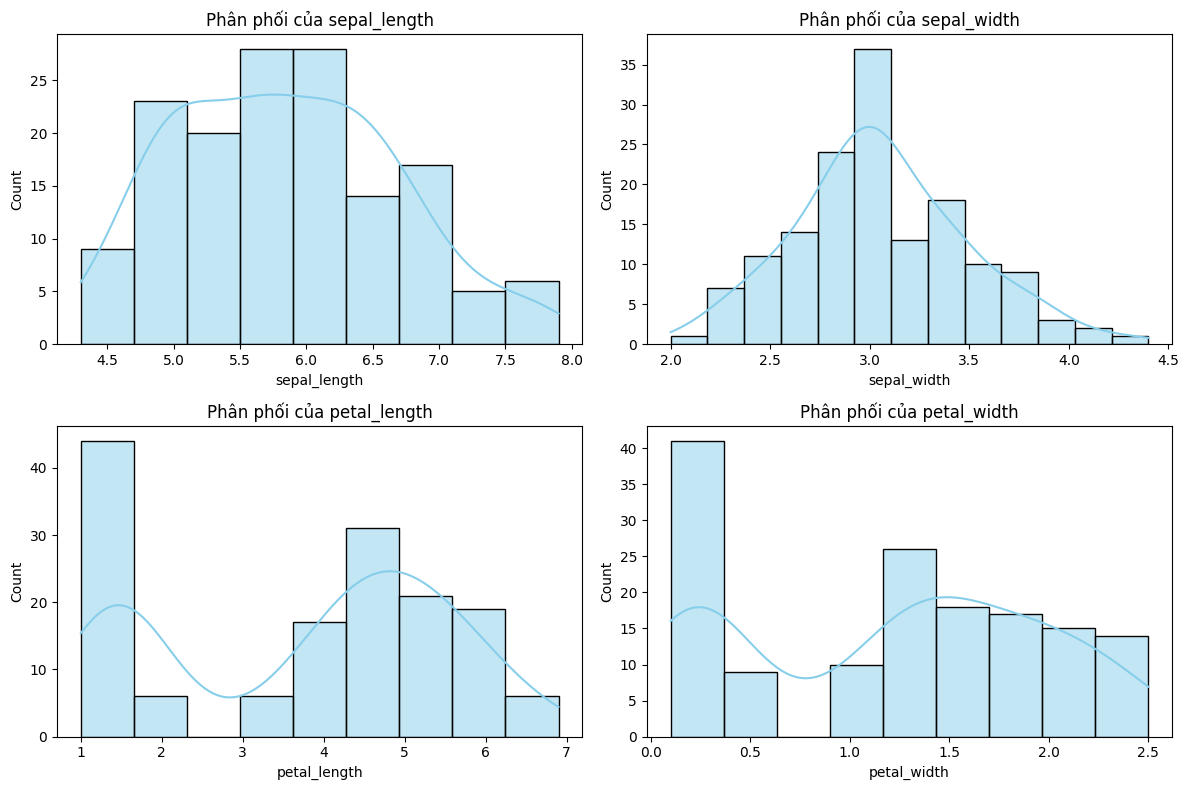

In [4]:

import matplotlib.pyplot as plt

# Tạo khung hình 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
print(axes)
axes = axes.flatten() # Trải phẳng mảng axes để dễ đưa vào vòng lặp

for i, col in enumerate(list_name_column):
    # Vẽ histogram và đường KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()


Nhận xét:

Biểu đồ sepal_length (Góc trên bên trái): Dữ liệu tập trung nhiều ở phía bên trái (khu vực 5.0 - 6.0) và đuôi có xu hướng kéo dài đi xuống về phía bên phải (khu vực 7.0 - 8.0) => Phân phối hơi lệch phải (right-skewed).

Biểu đồ sepal_width (Góc trên bên phải): Đây là biến có phân phối đối xứng nhất, đường cong KDE tạo thành hình chuông rất đẹp => Dữ liệu gần với phân phối chuẩn (Normal distribution) nhất và chỉ có một đỉnh (unimodal).

Biểu đồ petal_length và petal_width (Hai hàng dưới): Cả hai biểu đồ này đều bị tách làm 2 cụm hoàn toàn rời rạc: một cụm hẹp, cao nằm sát bên trái (giá trị nhỏ) và một cụm rộng hơn nằm bên phải (giá trị lớn) => Đây là dạng phân phối nhiều đỉnh (cụ thể ở đây là hai đỉnh - bimodal).

Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

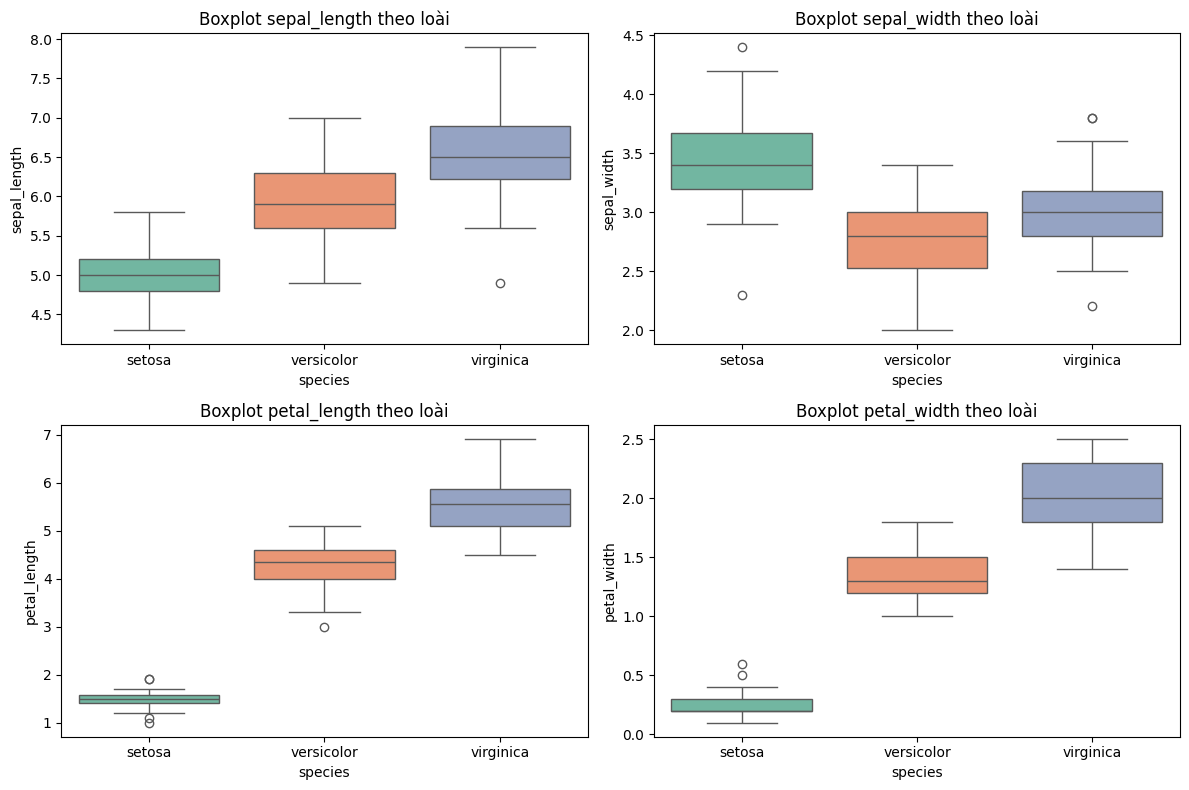

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(list_name_column):
    # Vẽ boxplot phân nhóm theo 'species'
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2', hue ='species')
    axes[i].set_title(f'Boxplot {col} theo loài')

plt.tight_layout()
plt.show()

Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp.
Chọn biến sepal_width

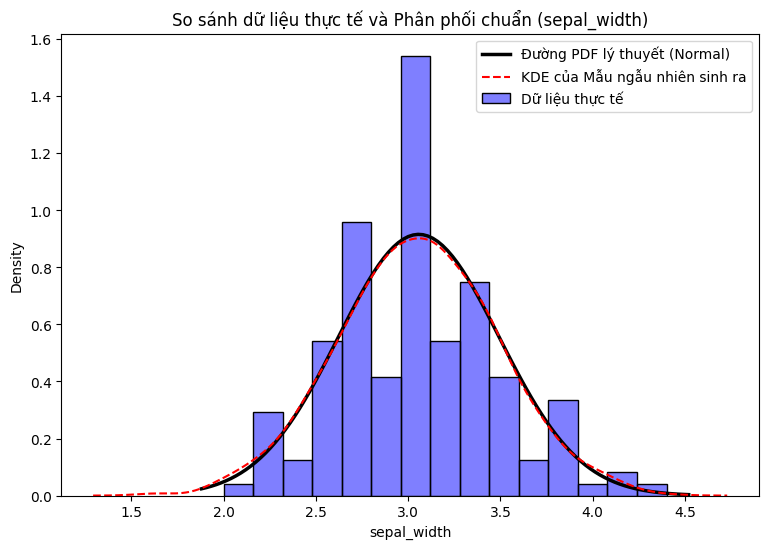

In [6]:
import scipy.stats as stats
import numpy as np
# Chọn biến (sepal_width) và tính tham số
bien_chon = 'sepal_width'
data = df[bien_chon]
mean_val = data.mean()
std_val = data.std()

# Sinh mẫu ngẫu nhiên từ phân phối Normal
mau_mo_phong = np.random.normal(mean_val, std_val, size=1000)
plt.figure(figsize=(9, 6))

# Vẽ histogram dữ liệu thực tế
# Lưu ý: stat='density' chuyển trục Y thành mật độ xác suất để có thể vẽ chung với PDF
sns.histplot(data, bins=15, stat='density', color='blue', alpha=0.5, label='Dữ liệu thực tế')
# alpha = 1.0: Màu đặc, che khuất hoàn toàn mọi thứ phía sau (mặc định).
# alpha = 0.0: Tàng hình hoàn toàn.
# alpha = 0.5: Mờ mờ ảo ảo (giống như nhìn qua một tấm kính màu).


# Vẽ đường PDF (Hàm mật độ xác suất) lý thuyết
# Khởi tạo trục x dựa trên giới hạn của biểu đồ hiện tại
x_min, x_max = plt.xlim()
x = np.linspace(x_min, x_max, 100)
pdf_ly_thuyet = stats.norm.pdf(x, mean_val, std_val)

plt.plot(x, pdf_ly_thuyet, 'k', linewidth=2.5, label='Đường PDF lý thuyết (Normal)')

# vẽ thêm đường KDE của tập mẫu vừa sinh ra để so sánh
sns.kdeplot(mau_mo_phong, color='red', linestyle='--', label='KDE của Mẫu ngẫu nhiên sinh ra')

plt.title(f'So sánh dữ liệu thực tế và Phân phối chuẩn ({bien_chon})')
plt.xlabel(bien_chon)
plt.legend()
plt.show()


Nhận xét: hai đường PDF lý thuyết và KDE của mẫu nhìn tổng thể có mức độ khớp khá tốt.

Bài 3: Phân tích đa biến & tương quan



In [7]:
df_numeric = df.select_dtypes(include = 'number')

cov = df_numeric.cov()
print("Ma trận Hiệp phương sai (Covariance):")
display(cov.round(3))
print()
corr = df_numeric.corr()
print("Ma trận Tương quan (Correlation):")
display(corr.round(3))

Ma trận Hiệp phương sai (Covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.686,-0.042,1.274,0.516
sepal_width,-0.042,0.190,-0.330,-0.122
petal_length,1.274,-0.330,3.116,1.296
petal_width,0.516,-0.122,1.296,0.581



Ma trận Tương quan (Correlation):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


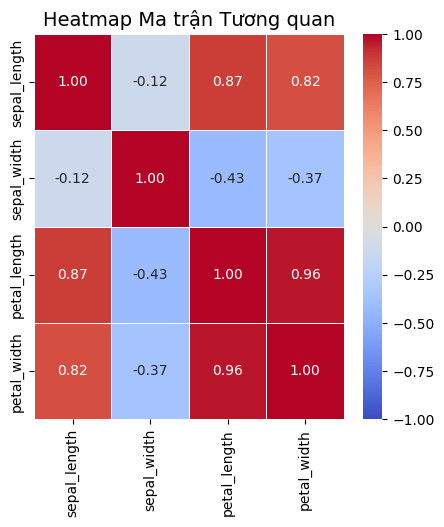

In [8]:
fig, ax = plt.subplots(figsize=(5,5))
# annot=True: hiển thị con số lên ô màu
# cmap='coolwarm': dải màu từ xanh (âm) sang đỏ (dương)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f",vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap Ma trận Tương quan', fontsize=14)
plt.show()

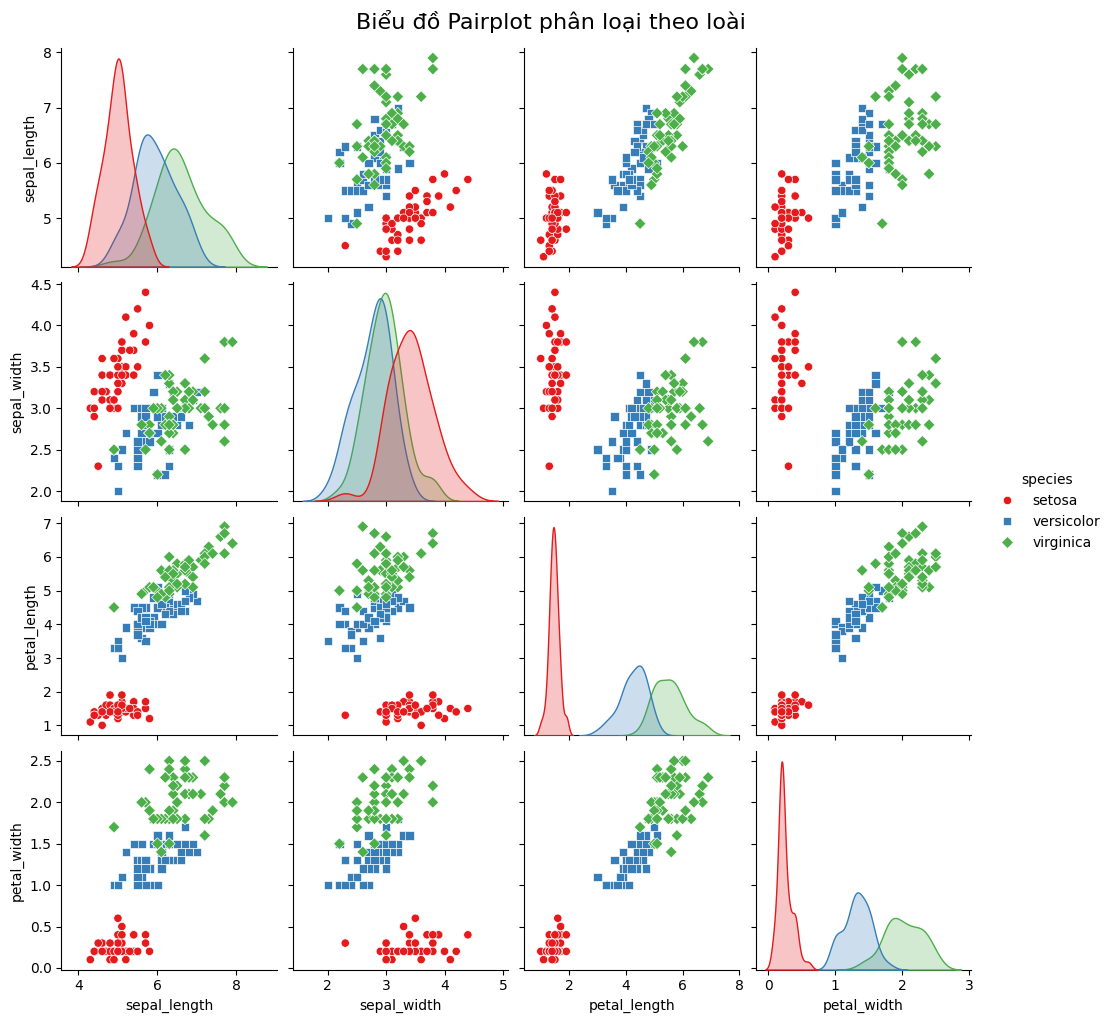

In [9]:
# Vẽ pairplot trên toàn bộ dataframe (bao gồm cả cột species để tô màu)
# hue='species': tô màu các điểm dữ liệu dựa theo loài
sns.pairplot(df, hue='species', palette='Set1', markers=["o", "s", "D"])

# chỉnh tọa độ y cao lên để không bị đè
plt.suptitle('Biểu đồ Pairplot phân loại theo loài', y=1.02, fontsize=16)
plt.show()

Nhận xét:

Các biến có tương quan tuyến tính dương mạnh với nhau, đặc biệt là cặp petal_length và petal_width.

Loài Setosa có kích thước nhỏ nhất và nằm tách biệt hoàn toàn thành một cụm riêng, rất dễ phân loại.

Loài Versicolor và Virginica có cùng xu hướng kích thước (Virginica lớn hơn) nhưng bị giao thoa (chồng lấn) nhẹ lên nhau.

Bài 4: Xác suất & Định lý Bayes

Bài toán chẩn đoán. Một bệnh có tỉ lệ mắc trong dân số là P (B) = 0.01. Một xét nghiệm có:

Độ nhạy (true positive): P (+ |B) = 0.99.
Dương tính giả (false positive): P (+ |¬B) = 0.05.


In [10]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos
print("XS hậu nghiệm P(B|+) =",round(P_B_given_pos , 4))

XS hậu nghiệm P(B|+) = 0.1667


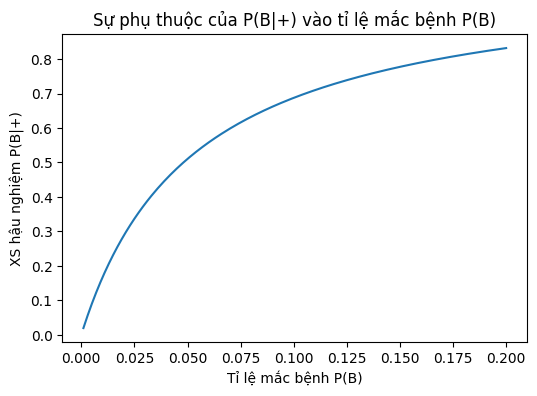

In [11]:
P_B = np.linspace(0.001, 0.2, 200)
P_pos_givenB = 0.99
P_pos_givnNB = 0.05
P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(P_B, P_B_given_pos)
plt.title("Sự phụ thuộc của P(B|+) vào tỉ lệ mắc bệnh P(B)")
plt.xlabel('Tỉ lệ mắc bệnh P(B)')
plt.ylabel('XS hậu nghiệm P(B|+)')
plt.show()

Sự "phản trực giác" xảy ra do tỷ lệ mắc bệnh trong dân số quá thấp (1%). Mặc dù tỷ lệ xét nghiệm sai sót thấp (5%), nhưng 5% của một nhóm người khỏe mạnh khổng lồ sẽ tạo ra lượng "Dương tính giả" lớn hơn rất nhiều so với 99% chẩn đoán đúng trên nhóm người bệnh nhỏ bé.

Hệ quả: Khi cầm kết quả dương tính, tỷ lệ rơi vào nhóm "khỏe mạnh bị chẩn đoán nhầm" vẫn cao hơn nhóm "thực sự mắc bệnh hiếm".